# Joint Runs info

I'm gonna join several summaries with the same thresholds to see what happens in the data with more statistics

In [1]:
import glob
import operator
import numpy as np
import pandas as pd
import tables as tb
from time import time


run_numbers = [15107, 15180] #[15107, 15114, 15116, 15152, 15153, 15155, 15164, 15176, 15178, 15179, 15180]

# [15107, 15114, 15116, 15152, 15153, 15155, 15164, 15176, 15178, 15179, 15180, 15193, 15195, 15201, 15205, 15206, 15208, 15214, 15216, 15229, 15230, 15231, 15232, 15233]

path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/{run_number}/'

all_info_path = path + 'run_summary.h5' # 'all_info_summary_new_E.h5'


save_path_summary = path + 'summary_info_cut_runs_{}_{}_3k_S2ecut_Zmin.h5'.format(run_numbers[0], run_numbers[-1])

# CUTS

min_dt, max_dt = 0, 1500

S2e_cut = True #if true, performs the new cut before doing the selection and recalculates the ns2
s2e_peak_cut = 3000 #cut on the S2 energy peaks

ns1, ns2 = 1, 1
s1_cond, s2_cond = '==', '=='

ener_cut = None #'Ec' #'S2e' # None
min_s2e, max_s2e = 200000, 400000 # if 'S2e
min_Ec, max_Ec = 1.5, 1.8 # if Ec


op_dct = {'==':operator.eq, '>=':operator.ge}
s1_op, s2_op = op_dct[s1_cond], op_dct[s2_cond]

data = {
    'runs': str(run_numbers),  # Convert list to string
    'dt_cut_min': min_dt,      # Split into separate columns
    'dt_cut_max': max_dt,
    'S2e_cut_flag': S2e_cut,
    'S2e_cut_value': s2e_peak_cut,
    'nS1': ns1,
    'S1_cond': s1_cond,
    'nS2': ns2,
    'S2_cond':s2_cond,
    'E_cut': str(ener_cut),
    'E_S2e_cut_min': min_s2e,
    'E_S2e_cut_max': max_s2e,
    'E_Ec_cut_min': min_Ec,
    'E_Ec_cut_max': max_Ec
}

cut_info = pd.DataFrame(data, index=[0])  # Single-row DataFrame
cut_info.to_hdf(save_path_summary.format(run_number=''), key='Summary/Cuts', mode='a', append=True)

for run_n in run_numbers:
    print('Appending Run {}'.format(run_n))
    t = time()
    dst       = pd.read_hdf(all_info_path.format(run_number = run_n), 'DST/Events')
    reco_summ = pd.read_hdf(all_info_path.format(run_number = run_n), 'RECO/Events_summary')
    print('Loaded data in {:.2f} s'.format(time() - t))
    t = time()
    
    dt_dst = dst[(dst.DT > min_dt) & (dst.DT < max_dt)] 

    if S2e_cut:
        dt_S2e_dst = dt_dst[dt_dst.S2e > s2e_peak_cut]
        # We did a cut in the S2 energy on the peaks, and compute again the nS1 and nS2
        dt_S2e_dst = dt_S2e_dst.merge(dt_S2e_dst.groupby('event').agg(ns1 = ('s1_peak', lambda x: x.nunique()), 
                                                                      ns2 = ('s2_peak', lambda x: x.nunique())).reset_index(), how ='left')
        dt_dst = dt_S2e_dst.copy()
        ns_names = ['ns1', 'ns2']
    else:
        ns_names = ['nS1', 'nS2']
    
    dt_ns_dst = dt_dst[s1_op(dt_dst[ns_names[0]], ns1) & s2_op(dt_dst[ns_names[1]], ns2)]
    
    if ener_cut == 'S2e':
        dt_ns_dst = dt_ns_dst[(dt_ns_dst.S2e > min_s2e) & (dt_ns_dst.S2e < max_s2e)]
    
    cut_dst = dt_ns_dst.copy()
    del(dt_ns_dst)
    # Add run_number
    cut_dst['run_n'] = run_n
    
    # Instead of just selecting by event, I do this for the cases where I did a S2e_cut (and re-count the number of S2 after the cuts) 
    # --> will affect always even if the S2e cut I do is lower than the cut done in the processing, because when we do the re-count, we already filtered in 
    # If the cut is not done, it should do nothing to the file because the dst already had just 1 row per event
    # merge to get all combinations
    cut_reco = reco_summ.merge(cut_dst[['event', 'S2e', ns_names[1]]], on=['event']).assign(d=lambda x: (x.S2e - x.total_E).abs())
    #do a ranking on the distance per event and per peak
    cut_reco['ranking'] = cut_reco.groupby(['event', 'npeak'])['d'].rank()
    #pick for each event and peak the closes one
    cut_reco = cut_reco[cut_reco['ranking'] == 1]

    #re-do the ranking, now just by the event, to eliminate the peaks that aren't in the dst
    cut_reco['ranking'] = cut_reco.groupby(['event'])['d'].rank()

    cut_reco = cut_reco[cut_reco.ranking <= cut_reco[ns_names[1]]].drop(columns = ['S2e', 'ns2', 'd'])

    # To cut in Ec it has to be done after all the DST cuts are done, and the RECO is adjusted to match the DST peaks selected, not before
    if ener_cut == 'Ec':
        # We cut in the corrected energy, and pick those events
        tot_e_group = cut_reco.groupby(['event', 'run_n', 'file_n', 'ldc_n']).sum().reset_index()
        reco_E_events = tot_e_group[(tot_e_group.total_energy > min_Ec) & (tot_e_group.total_energy < max_Ec)].event.unique()
        cut_dst  = cut_dst [np.isin(cut_dst.event,  reco_E_events)]
        cut_reco = cut_reco[np.isin(cut_reco.event, reco_E_events)]

    del(reco_summ)
    cut_dst .to_hdf (save_path_summary.format(run_number = ''), key = 'Summary/DST', mode = 'a', append= True)
    cut_reco.to_hdf(save_path_summary.format(run_number = ''), key = 'Summary/RECO', mode = 'a', append= True)
    print('Processed data in {:.2f} s'.format(time() - t))


Appending Run 15107
Loaded data in 0.34 s
Processed data in 3.94 s
Appending Run 15180
Loaded data in 172.07 s
Processed data in 62.19 s


In [31]:
import matplotlib.pyplot as plt

In [2]:
cut_dst

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Zrms,X,Y,R,Phi,Xrms,Yrms,ns1,ns2,run_n
0,2,1.743951e+09,0,0,1,1,325.0,56.168129,324.301636,767225.0,...,25.238834,223.030439,1.940618,223.038882,0.008701,260.825795,187.164917,1,1,15180
1,9,1.743951e+09,0,0,1,1,475.0,9.633460,59.439648,985275.0,...,8.148502,99.386582,73.247382,123.462025,0.635126,272.261547,241.609138,1,1,15180
2,23,1.743951e+09,0,0,1,1,650.0,38.996037,242.110916,805900.0,...,48.645109,59.137358,117.161214,131.240151,1.103354,193.680767,214.851554,1,1,15180
3,30,1.743951e+09,0,0,1,2,350.0,30.065920,181.411240,393625.0,...,12.781587,113.780622,166.477091,201.644865,0.971257,225.269535,243.749106,1,1,15180
27,93,1.743951e+09,0,0,1,1,325.0,47.161869,258.271271,699300.0,...,38.700746,152.987611,87.491444,176.238367,0.519491,242.254810,200.649841,1,1,15180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029719,2884986,1.744014e+09,0,0,1,1,350.0,84.832260,473.145172,488650.0,...,36.239035,163.474784,115.937511,200.413352,0.616879,216.459071,191.686465,1,1,15180
2029722,2885007,1.744014e+09,0,0,1,1,350.0,11.408064,70.548546,867350.0,...,9.131312,69.262743,78.207717,104.469013,0.845980,244.008872,240.452779,1,1,15180
2029727,2885021,1.744014e+09,0,1,1,2,325.0,63.399387,325.755859,701500.0,...,25.685859,136.225031,179.400719,225.259577,0.921348,211.568559,227.432972,1,1,15180
2029730,2885070,1.744014e+09,0,0,1,1,350.0,6.703202,41.470524,1129850.0,...,7.844112,-58.077344,93.460464,110.035614,2.126810,236.009155,243.612257,1,1,15180


In [25]:
zneg_reco = cut_reco[cut_reco.Z_min < 0]
zneg_dst = zneg_reco[['event']].drop_duplicates().merge(cut_dst, on = ['event'])

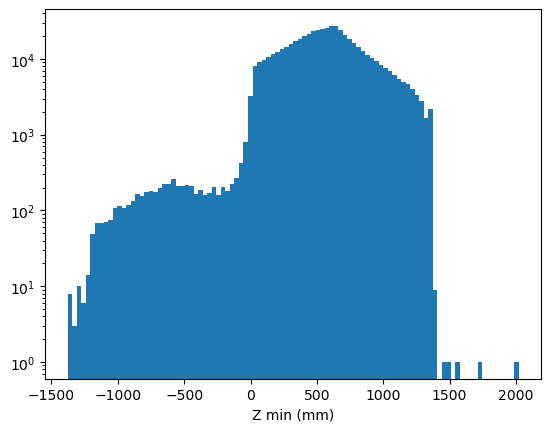

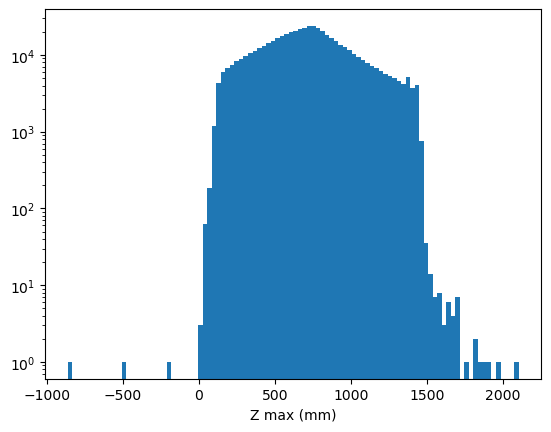

In [28]:
plt.hist(cut_reco.Z_min, 100)
plt.yscale('log')
plt.xlabel('Z min (mm)')
plt.show()
plt.hist(cut_reco.Z_min + cut_reco.dZ, 100)
plt.yscale('log')
plt.xlabel('Z max (mm)')
plt.show()

In [45]:
plt.cm.viridis.set_bad(color='white', alpha=0)
plt.cm.viridis.set_under(color='white', alpha=0) 

/scratch/12823245/ipykernel_1125439/1639480895.py:1: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("viridis").copy()
  plt.cm.viridis.set_bad(color='white', alpha=0)
/scratch/12823245/ipykernel_1125439/1639480895.py:2: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("viridis").copy()
  plt.cm.viridis.set_under(color='white', alpha=0)


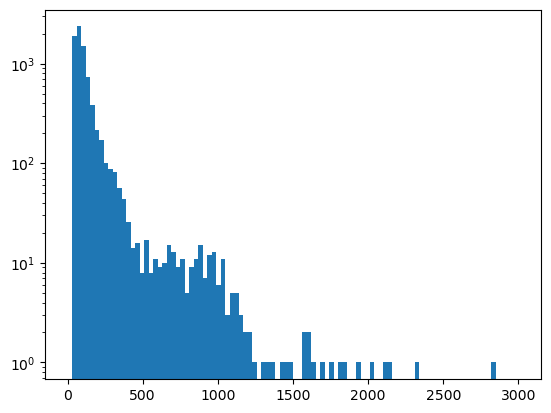

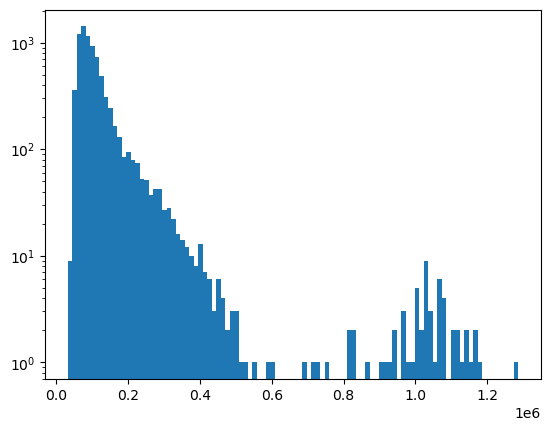

In [46]:
plt.hist(zneg_dst.S1e, 100, (0, 3000))
plt.yscale('log')
plt.show()
plt.hist(zneg_dst.S2e, 100)
plt.yscale('log')
plt.show()

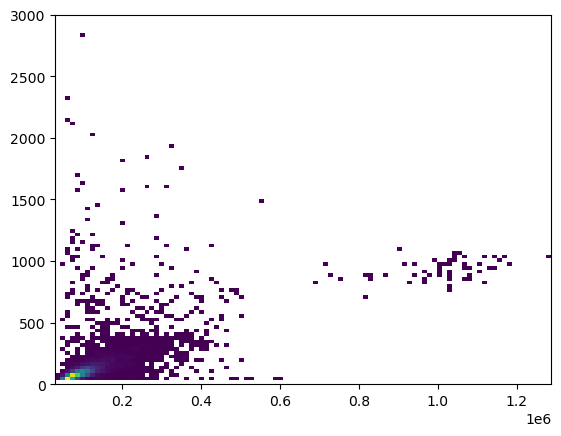

In [ ]:
cmap = plt.cm.viridis.copy()
cmap.set_under('white') 
plt.hist2d(zneg_dst.S2e, zneg_dst.S1e, 100, (None, (0, 3000)), cmap = cmap, vmin = 1)
plt.show()

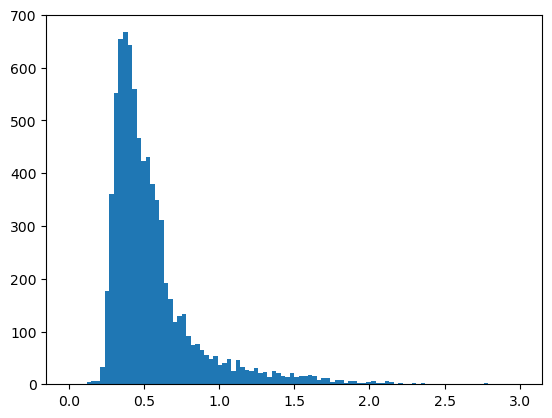

In [29]:
plt.hist(zneg_reco.total_energy, 100, (0, 3))
plt.show()

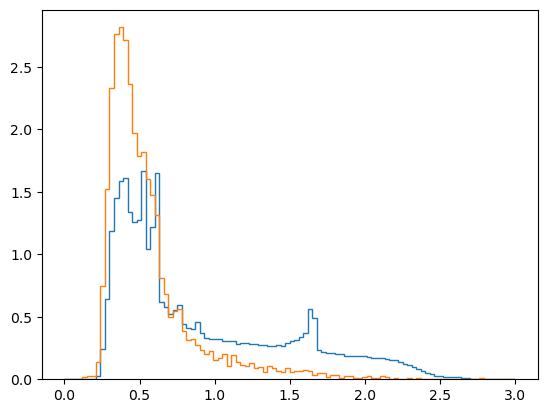

In [56]:
plt.hist(cut_reco.groupby('event').sum().total_energy, 100, (0, 3), density=True, histtype='step')
plt.hist(zneg_reco.total_energy, 100, (0, 3), density=True, histtype='step')
plt.show()

In [157]:
def read_summary_info(path):
    dst_info  = pd.read_hdf(path, 'Summary/DST')
    reco_info = pd.read_hdf(path, 'Summary/RECO')
    cut_info  = pd.read_hdf(path, 'Summary/Cuts')
    reco_info['rad'] = np.sqrt(reco_info['X_bary'] ** 2 + reco_info['Y_bary'] ** 2)
    reco_info['run_n_int'] = reco_info.run_n.astype('int')
    return dst_info, reco_info, cut_info

dst_info_1, reco_info_1, cut_info_1 = read_summary_info(path.format(run_number = '') + 'summary_info_cut_runs_15195_15233_{}.h5'.format('3k_S2ecut'))


In [159]:
len(cut_dst), len(cut_reco)

(6760, 6760)

In [160]:
len(dst_info_1[dst_info_1.run_n == 15201]), len(reco_info_1[reco_info_1.run_n == '15201'])

(6760, 6760)

In [123]:
m

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits,S2e,ns2,d,ranking
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,93119.158241,0.466323,11.314883,605,117230.125000,1,24110.966759,2.0
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878,117230.125000,1,14.099470,1.0
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783,151494.968750,1,14.053429,1.0
3,590,0,15107,0000,ldc1,1.742935e+09,926.00,957.10,123.355250,283.541438,25.836635,299.965370,322672.703091,1.639312,39.000286,2098,322680.343750,1,7.640659,1.0
4,597,29,15107,0000,ldc1,1.742935e+09,957.10,941.55,120.013500,168.605345,104.067490,917.221973,105203.858832,0.534775,12.384103,784,105222.789062,1,18.930230,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55151,1540930,0,15107,2243,ldc7,1.742955e+09,972.65,972.65,109.907250,159.305323,-197.202484,273.980832,302778.628486,1.509766,35.961926,1664,302798.125000,1,19.496514,1.0
55152,1541133,23,15107,2244,ldc7,1.742955e+09,941.55,864.30,107.723375,391.546253,119.204752,286.233493,87825.170024,0.494593,11.757543,533,87836.789062,1,11.619038,1.0
55153,1542806,27,15107,2246,ldc7,1.742955e+09,972.65,972.65,120.429000,196.147436,-285.456796,685.437449,114220.232779,0.596802,13.981495,698,114237.234375,1,17.001596,1.0
55154,1543072,28,15107,2247,ldc7,1.742955e+09,972.65,972.65,147.913000,-31.707374,174.037937,286.225965,55784.500950,0.270075,6.414972,334,55839.617188,1,55.116237,1.0


In [115]:
cut_dst

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Zrms,X,Y,R,Phi,Xrms,Yrms,ns1,ns2,run_n
0,156,1.742935e+09,0,1,1,2,600.0,24.381660,136.866943,619825.0,...,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738,1,1,15107
1,275,1.742935e+09,0,0,1,1,375.0,20.105528,130.680893,1217525.0,...,18.371055,15.761644,-65.178615,67.057299,-1.333529,190.955556,208.454665,1,1,15107
5,590,1.742935e+09,0,0,1,1,400.0,41.841473,240.074432,1139325.0,...,29.010471,170.053074,19.509000,171.168482,0.114224,217.766683,168.386432,1,1,15107
6,597,1.742935e+09,0,0,1,1,650.0,16.592751,97.683167,493475.0,...,9.251109,75.948209,52.021293,92.056208,0.600559,214.760246,197.605371,1,1,15107
7,674,1.742935e+09,0,0,1,2,700.0,24.888544,130.439056,499400.0,...,12.620832,127.688141,-25.099654,130.131680,-0.194095,245.149160,203.794454,1,2,15107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114636,1543520,1.742955e+09,0,0,1,3,300.0,56.595901,313.335785,883525.0,...,16.295943,99.715135,36.898587,106.323158,0.354415,182.613898,168.155991,1,2,15107
114637,1543520,1.742955e+09,0,1,1,3,300.0,56.595901,313.335785,883525.0,...,28.874973,126.694342,-58.176895,139.413082,-0.430471,217.690277,194.764712,1,2,15107
114638,1543639,1.742955e+09,0,0,1,1,325.0,42.446838,255.767807,864150.0,...,27.476889,-87.031816,-121.836491,149.728646,-2.191077,212.851809,231.818528,1,1,15107
114639,1543695,1.742955e+09,0,0,1,2,550.0,141.545319,841.084045,965675.0,...,5.894291,-163.943239,-150.348484,222.445616,-2.399423,239.700110,238.387988,1,2,15107


In [5]:
import matplotlib.pyplot as plt

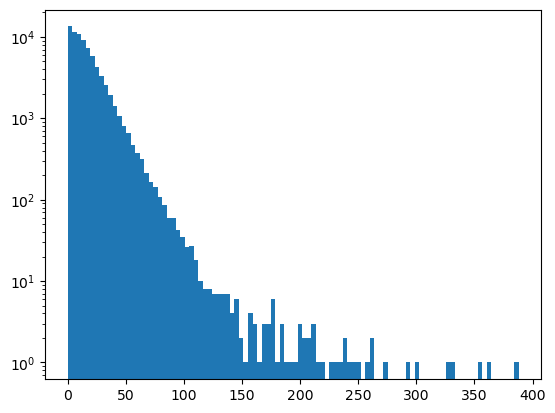

In [102]:
plt.hist(m[m.ranking <= m.ns2].d, 100)
plt.yscale('log')
plt.show()

In [97]:
cut_dst

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Zrms,X,Y,R,Phi,Xrms,Yrms,ns1,ns2,run_n
0,156,1.742935e+09,0,1,1,2,600.0,24.381660,136.866943,619825.0,...,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738,1,1,15107
1,275,1.742935e+09,0,0,1,1,375.0,20.105528,130.680893,1217525.0,...,18.371055,15.761644,-65.178615,67.057299,-1.333529,190.955556,208.454665,1,1,15107
5,590,1.742935e+09,0,0,1,1,400.0,41.841473,240.074432,1139325.0,...,29.010471,170.053074,19.509000,171.168482,0.114224,217.766683,168.386432,1,1,15107
6,597,1.742935e+09,0,0,1,1,650.0,16.592751,97.683167,493475.0,...,9.251109,75.948209,52.021293,92.056208,0.600559,214.760246,197.605371,1,1,15107
7,674,1.742935e+09,0,0,1,2,700.0,24.888544,130.439056,499400.0,...,12.620832,127.688141,-25.099654,130.131680,-0.194095,245.149160,203.794454,1,2,15107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114636,1543520,1.742955e+09,0,0,1,3,300.0,56.595901,313.335785,883525.0,...,16.295943,99.715135,36.898587,106.323158,0.354415,182.613898,168.155991,1,2,15107
114637,1543520,1.742955e+09,0,1,1,3,300.0,56.595901,313.335785,883525.0,...,28.874973,126.694342,-58.176895,139.413082,-0.430471,217.690277,194.764712,1,2,15107
114638,1543639,1.742955e+09,0,0,1,1,325.0,42.446838,255.767807,864150.0,...,27.476889,-87.031816,-121.836491,149.728646,-2.191077,212.851809,231.818528,1,1,15107
114639,1543695,1.742955e+09,0,0,1,2,550.0,141.545319,841.084045,965675.0,...,5.894291,-163.943239,-150.348484,222.445616,-2.399423,239.700110,238.387988,1,2,15107


In [46]:
reco_summ.head(20)

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,93119.158241,0.466323,11.314883,605
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783
3,317,4,15107,0000,ldc1,1.742935e+09,941.55,910.45,59.131687,146.315026,-24.024491,-4.502623,26659.294334,0.132493,3.188627,146
4,317,12,15107,0000,ldc1,1.742935e+09,926.00,848.75,64.224250,138.550281,288.066607,454.527914,4564.980680,0.025331,0.599311,38
5,317,14,15107,0000,ldc1,1.742935e+09,957.10,926.00,114.720125,294.538001,285.985614,843.507058,163915.730585,0.946430,21.908902,1223
6,478,4,15107,0000,ldc1,1.742935e+09,879.35,926.00,104.393250,194.523563,239.989813,34.456065,39431.360065,0.205083,4.926612,302
7,478,24,15107,0000,ldc1,1.742935e+09,972.65,879.35,101.310750,204.440655,-170.228850,1234.602202,58673.427549,0.303981,6.952804,311
8,590,0,15107,0000,ldc1,1.742935e+09,926.00,957.10,123.355250,283.541438,25.836635,299.965370,322672.703091,1.639312,39.000286,2098
9,597,29,15107,0000,ldc1,1.742935e+09,957.10,941.55,120.013500,168.605345,104.067490,917.221973,105203.858832,0.534775,12.384103,784


In [45]:
cut_dst.head(10)

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Zrms,X,Y,R,Phi,Xrms,Yrms,ns1,ns2,run_n
0,156,1.742935e+09,0,1,1,2,600.0,24.381660,136.866943,619825.0,...,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738,1,1,15107
1,275,1.742935e+09,0,0,1,1,375.0,20.105528,130.680893,1217525.0,...,18.371055,15.761644,-65.178615,67.057299,-1.333529,190.955556,208.454665,1,1,15107
5,590,1.742935e+09,0,0,1,1,400.0,41.841473,240.074432,1139325.0,...,29.010471,170.053074,19.509000,171.168482,0.114224,217.766683,168.386432,1,1,15107
6,597,1.742935e+09,0,0,1,1,650.0,16.592751,97.683167,493475.0,...,9.251109,75.948209,52.021293,92.056208,0.600559,214.760246,197.605371,1,1,15107
7,674,1.742935e+09,0,0,1,2,700.0,24.888544,130.439056,499400.0,...,12.620832,127.688141,-25.099654,130.131680,-0.194095,245.149160,203.794454,1,2,15107
8,674,1.742935e+09,0,1,1,2,700.0,24.888544,130.439056,499400.0,...,11.406402,38.743186,131.437556,137.028704,1.284149,204.899288,247.231652,1,2,15107
9,842,1.742935e+09,0,0,1,1,525.0,12.493229,65.339417,1063975.0,...,5.722175,42.126927,103.311975,111.570794,1.183615,193.032714,207.339490,1,1,15107
10,1073,1.742935e+09,0,1,1,3,350.0,21.361202,119.546326,1026925.0,...,20.708506,86.956529,21.804043,89.648503,0.245681,198.876725,199.794691,1,2,15107
11,1073,1.742935e+09,0,2,1,3,350.0,21.361202,119.546326,1026925.0,...,5.761484,-234.106197,-135.170510,270.327169,-2.617964,236.652593,174.715371,1,2,15107
12,1318,1.742935e+09,0,0,1,3,725.0,28.566357,157.433044,197225.0,...,5.811020,-68.205766,-116.764817,135.225919,-2.099465,223.476872,292.433411,1,2,15107


In [36]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,93119.158241,0.466323,11.314883,605
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783
3,317,4,15107,0000,ldc1,1.742935e+09,941.55,910.45,59.131687,146.315026,-24.024491,-4.502623,26659.294334,0.132493,3.188627,146
4,317,12,15107,0000,ldc1,1.742935e+09,926.00,848.75,64.224250,138.550281,288.066607,454.527914,4564.980680,0.025331,0.599311,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1543611,11,15107,2247,ldc7,1.742955e+09,941.55,957.10,65.860719,-78.221234,106.761913,30.526851,23775.899290,0.116165,2.791897,230
5,1543611,34,15107,2247,ldc7,1.742955e+09,910.45,894.90,95.486875,-25.533748,245.984778,1015.528444,53793.544661,0.281955,6.525307,240
6,1543639,1,15107,2247,ldc7,1.742955e+09,957.10,972.65,157.661250,-181.176193,-260.373339,543.114826,280861.403903,1.514937,35.791170,1964
7,1543695,20,15107,2247,ldc7,1.742955e+09,926.00,972.65,96.194500,-314.793696,-298.092817,442.032764,145471.945855,0.739055,17.761517,582


In [ ]:
m.loc[m.groupby(reco_summ.index)['d'].idxmin()]

,event,npeak,run_n,file_n,ldc_n,time_x,dX,dY,dZ,X_bary,...,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,d
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,...,-218.339066,-218.339066,19.622758,137.029985,27.834735,139.828428,0.200402,240.724924,195.344402,0.009804
1,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,...,787.668030,787.668030,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738,24110.966759
2,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,...,-218.339066,-218.339066,19.622758,137.029985,27.834735,139.828428,0.200402,240.724924,195.344402,24096.877092
3,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,...,787.668030,787.668030,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738,14.099470
4,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,...,185.960632,185.960632,18.371055,15.761644,-65.178615,67.057299,-1.333529,190.955556,208.454665,14.053429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506626,1543639,1,15107,2247,ldc7,1.742955e+09,957.10,972.65,157.661250,-181.176193,...,550.339417,550.339417,27.476889,-87.031816,-121.836491,149.728646,-2.191077,212.851809,231.818528,7.939847
506627,1543695,20,15107,2247,ldc7,1.742955e+09,926.00,972.65,96.194500,-314.793696,...,441.808014,441.808014,5.894291,-163.943239,-150.348484,222.445616,-2.399423,239.700110,238.387988,10.866645
506628,1543695,20,15107,2247,ldc7,1.742955e+09,926.00,972.65,96.194500,-314.793696,...,903.817566,903.817566,7.250740,80.152813,101.002795,128.941995,0.899988,244.577584,239.391046,104211.898980
506629,1543695,25,15107,2247,ldc7,1.742955e+09,941.55,848.25,99.874625,241.483272,...,441.808014,441.808014,5.894291,-163.943239,-150.348484,222.445616,-2.399423,239.700110,238.387988,104227.398361


In [23]:
dst

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
0,156,1.742935e+09,0,0,1,2,600.0,24.381660,136.866943,619825.0,...,2111,-218.339066,-218.339066,19.622758,137.029985,27.834735,139.828428,0.200402,240.724924,195.344402
1,156,1.742935e+09,0,1,1,2,600.0,24.381660,136.866943,619825.0,...,2152,787.668030,787.668030,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738
2,275,1.742935e+09,0,0,1,1,375.0,20.105528,130.680893,1217525.0,...,2539,185.960632,185.960632,18.371055,15.761644,-65.178615,67.057299,-1.333529,190.955556,208.454665
3,317,1.742935e+09,0,0,3,3,225.0,19.746523,148.996826,562650.0,...,776,-3.149063,-3.149063,3.503168,66.337331,2.219122,66.374438,0.033440,211.118392,194.975194
4,317,1.742935e+09,0,1,3,3,225.0,19.746523,148.996826,562650.0,...,724,452.851776,452.851776,6.683204,17.697822,39.607853,43.381966,1.150585,253.569501,263.959456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1543611,1.742955e+09,65535,0,0,2,NaN,NaN,NaN,NaN,...,919,NaN,NaN,6.084382,-31.488364,49.373509,58.559887,2.138518,216.236432,216.723605
5,1543611,1.742955e+09,65535,1,0,2,NaN,NaN,NaN,NaN,...,1679,NaN,NaN,6.578591,-1.907084,104.011263,104.028745,1.589130,208.236558,233.288108
6,1543639,1.742955e+09,0,0,1,1,325.0,42.446838,255.767807,864150.0,...,3144,550.339417,550.339417,27.476889,-87.031816,-121.836491,149.728646,-2.191077,212.851809,231.818528
7,1543695,1.742955e+09,0,0,1,2,550.0,141.545319,841.084045,965675.0,...,2231,441.808014,441.808014,5.894291,-163.943239,-150.348484,222.445616,-2.399423,239.700110,238.387988


In [24]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,93119.158241,0.466323,11.314883,605
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783
3,317,4,15107,0000,ldc1,1.742935e+09,941.55,910.45,59.131687,146.315026,-24.024491,-4.502623,26659.294334,0.132493,3.188627,146
4,317,12,15107,0000,ldc1,1.742935e+09,926.00,848.75,64.224250,138.550281,288.066607,454.527914,4564.980680,0.025331,0.599311,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1543611,11,15107,2247,ldc7,1.742955e+09,941.55,957.10,65.860719,-78.221234,106.761913,30.526851,23775.899290,0.116165,2.791897,230
5,1543611,34,15107,2247,ldc7,1.742955e+09,910.45,894.90,95.486875,-25.533748,245.984778,1015.528444,53793.544661,0.281955,6.525307,240
6,1543639,1,15107,2247,ldc7,1.742955e+09,957.10,972.65,157.661250,-181.176193,-260.373339,543.114826,280861.403903,1.514937,35.791170,1964
7,1543695,20,15107,2247,ldc7,1.742955e+09,926.00,972.65,96.194500,-314.793696,-298.092817,442.032764,145471.945855,0.739055,17.761517,582


In [16]:
len(reco_summ), len(dst)

(139518, 174567)

In [14]:
len(dst), len(cut_dst), len(reco_summ)

(174567, 76455, 139518)

In [6]:
cut_dst.head(10)

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Zrms,X,Y,R,Phi,Xrms,Yrms,ns1,ns2,run_n
0,156,1.742935e+09,0,1,1,2,600.0,24.381660,136.866943,619825.0,...,18.626027,116.011572,-55.936634,128.792826,-0.449277,221.975949,200.956738,1,1,15107
1,275,1.742935e+09,0,0,1,1,375.0,20.105528,130.680893,1217525.0,...,18.371055,15.761644,-65.178615,67.057299,-1.333529,190.955556,208.454665,1,1,15107
5,590,1.742935e+09,0,0,1,1,400.0,41.841473,240.074432,1139325.0,...,29.010471,170.053074,19.509000,171.168482,0.114224,217.766683,168.386432,1,1,15107
6,597,1.742935e+09,0,0,1,1,650.0,16.592751,97.683167,493475.0,...,9.251109,75.948209,52.021293,92.056208,0.600559,214.760246,197.605371,1,1,15107
7,674,1.742935e+09,0,0,1,2,700.0,24.888544,130.439056,499400.0,...,12.620832,127.688141,-25.099654,130.131680,-0.194095,245.149160,203.794454,1,2,15107
8,674,1.742935e+09,0,1,1,2,700.0,24.888544,130.439056,499400.0,...,11.406402,38.743186,131.437556,137.028704,1.284149,204.899288,247.231652,1,2,15107
9,842,1.742935e+09,0,0,1,1,525.0,12.493229,65.339417,1063975.0,...,5.722175,42.126927,103.311975,111.570794,1.183615,193.032714,207.339490,1,1,15107
10,1073,1.742935e+09,0,1,1,3,350.0,21.361202,119.546326,1026925.0,...,20.708506,86.956529,21.804043,89.648503,0.245681,198.876725,199.794691,1,2,15107
11,1073,1.742935e+09,0,2,1,3,350.0,21.361202,119.546326,1026925.0,...,5.761484,-234.106197,-135.170510,270.327169,-2.617964,236.652593,174.715371,1,2,15107
12,1318,1.742935e+09,0,0,1,3,725.0,28.566357,157.433044,197225.0,...,5.811020,-68.205766,-116.764817,135.225919,-2.099465,223.476872,292.433411,1,2,15107


In [3]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,93119.158241,0.466323,11.314883,605
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783
3,317,4,15107,0000,ldc1,1.742935e+09,941.55,910.45,59.131687,146.315026,-24.024491,-4.502623,26659.294334,0.132493,3.188627,146
4,317,12,15107,0000,ldc1,1.742935e+09,926.00,848.75,64.224250,138.550281,288.066607,454.527914,4564.980680,0.025331,0.599311,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1543611,11,15107,2247,ldc7,1.742955e+09,941.55,957.10,65.860719,-78.221234,106.761913,30.526851,23775.899290,0.116165,2.791897,230
5,1543611,34,15107,2247,ldc7,1.742955e+09,910.45,894.90,95.486875,-25.533748,245.984778,1015.528444,53793.544661,0.281955,6.525307,240
6,1543639,1,15107,2247,ldc7,1.742955e+09,957.10,972.65,157.661250,-181.176193,-260.373339,543.114826,280861.403903,1.514937,35.791170,1964
7,1543695,20,15107,2247,ldc7,1.742955e+09,926.00,972.65,96.194500,-314.793696,-298.092817,442.032764,145471.945855,0.739055,17.761517,582


In [8]:
reco_summ.merge(cut_dst[['event', 'S2e']], on='event').head(10)

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits,S2e
0,156,4,15107,0000,ldc1,1.742935e+09,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,93119.158241,0.466323,11.314883,605,117230.125000
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878,117230.125000
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783,151494.968750
3,590,0,15107,0000,ldc1,1.742935e+09,926.00,957.10,123.355250,283.541438,25.836635,299.965370,322672.703091,1.639312,39.000286,2098,322680.343750
4,597,29,15107,0000,ldc1,1.742935e+09,957.10,941.55,120.013500,168.605345,104.067490,917.221973,105203.858832,0.534775,12.384103,784,105222.789062
5,674,23,15107,0000,ldc1,1.742935e+09,926.00,972.65,119.747625,289.345142,-83.595571,603.809317,102014.095507,0.523332,12.331106,875,102037.453125
6,674,23,15107,0000,ldc1,1.742935e+09,926.00,972.65,119.747625,289.345142,-83.595571,603.809317,102014.095507,0.523332,12.331106,875,114241.984375
7,674,25,15107,0000,ldc1,1.742935e+09,972.65,941.55,130.083500,79.188351,307.398627,907.073216,114198.408713,0.604641,13.945190,743,102037.453125
8,674,25,15107,0000,ldc1,1.742935e+09,972.65,941.55,130.083500,79.188351,307.398627,907.073216,114198.408713,0.604641,13.945190,743,114241.984375
9,842,33,15107,0001,ldc1,1.742935e+09,941.55,894.90,87.896500,75.221543,188.582286,343.391377,78534.919971,0.393763,9.325307,389,78555.250000


In [9]:
cut_reco = reco_summ.merge(cut_dst[['event', 'S2e']], on='event').assign(d=lambda x: (x.S2e - x.total_E).abs()).sort_values(['ldc_n', 'file_n', 'event', 'd']).groupby('event').head(1).drop(columns = ['d', 'S2e'])


In [10]:
cut_reco

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_E,total_energy,total_geo_ener,num_hits
1,156,16,15107,0000,ldc1,1.742935e+09,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,117216.025530,0.601568,14.109211,878
2,275,3,15107,0000,ldc1,1.742935e+09,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,151480.915321,0.745806,17.798488,783
3,590,0,15107,0000,ldc1,1.742935e+09,926.00,957.10,123.355250,283.541438,25.836635,299.965370,322672.703091,1.639312,39.000286,2098
4,597,29,15107,0000,ldc1,1.742935e+09,957.10,941.55,120.013500,168.605345,104.067490,917.221973,105203.858832,0.534775,12.384103,784
5,674,23,15107,0000,ldc1,1.742935e+09,926.00,972.65,119.747625,289.345142,-83.595571,603.809317,102014.095507,0.523332,12.331106,875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178191,1542806,27,15107,2246,ldc7,1.742955e+09,972.65,972.65,120.429000,196.147436,-285.456796,685.437449,114220.232779,0.596802,13.981495,698
178192,1543072,28,15107,2247,ldc7,1.742955e+09,972.65,972.65,147.913000,-31.707374,174.037937,286.225965,55784.500950,0.270075,6.414972,334
178193,1543520,0,15107,2247,ldc7,1.742955e+09,957.10,957.10,73.540625,157.118394,51.551518,514.712763,165630.942613,0.830501,19.595911,1260
178199,1543639,1,15107,2247,ldc7,1.742955e+09,957.10,972.65,157.661250,-181.176193,-260.373339,543.114826,280861.403903,1.514937,35.791170,1964
